# Titanic Dataset Analysis – Task 3

## Mini Exploratory Data Analysis (EDA)

### Objectives
- Clean the dataset
- Analyze survival patterns
- Create meaningful visualizations
- Generate insights using groupby operations

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
%matplotlib inline

## Step 1: Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Dataset Overview

In [3]:
print("Shape of Dataset:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Step 3: Data Cleaning

### Tasks
- Fill missing Age values with mean
- Fill missing Embarked values with mode
- Drop Cabin column

In [4]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df.drop(columns=["Cabin"], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


# Analysis Question 1

## Survival Rate by Age Group

In [5]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=[
        "Child",
        "Teen",
        "YoungAdult",
        "Adult",
        "Senior"
    ]
)

age_survival = df.groupby(
    "AgeGroup",
    observed=False
)["Survived"].mean()*100

print(age_survival)

AgeGroup
Child         57.971014
Teen          42.857143
YoungAdult    33.109620
Adult         42.323651
Senior        34.375000
Name: Survived, dtype: float64


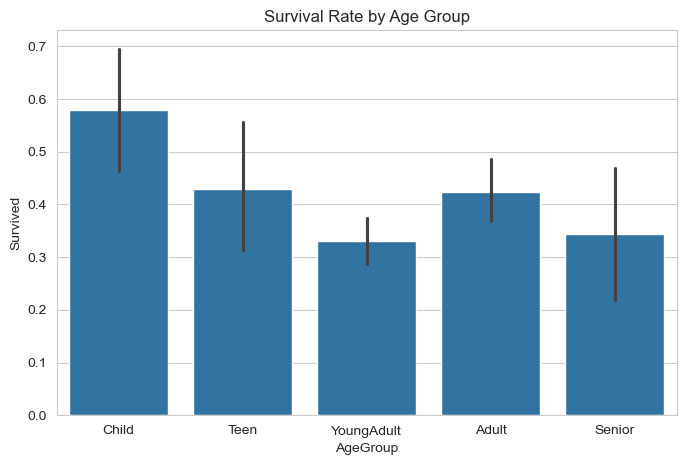

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="AgeGroup",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Age Group")

plt.show()

### Insight

Children generally had better survival chances.

# Analysis Question 2

## Survival Rate by Embarkation Port

In [7]:
embarked_survival = df.groupby(
    "Embarked"
)["Survived"].mean()*100

print(embarked_survival)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


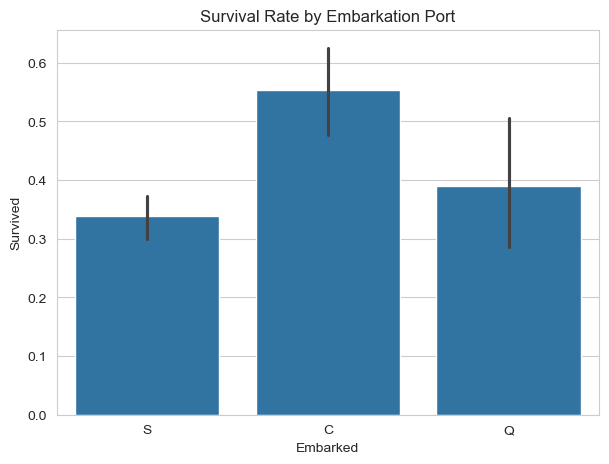

In [8]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="Embarked",
    y="Survived",
    data=df
)

plt.title(
    "Survival Rate by Embarkation Port"
)

plt.show()

### Insight

Passengers embarking from different ports had different survival rates.

# Analysis Question 3

## Survival Rate by Family Size

In [9]:
df["FamilySize"] = (
    df["SibSp"] +
    df["Parch"]
)

df[
    ["SibSp",
     "Parch",
     "FamilySize"]
].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [10]:
family_survival = df.groupby(
    "FamilySize"
)["Survived"].mean()*100

print(family_survival)

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


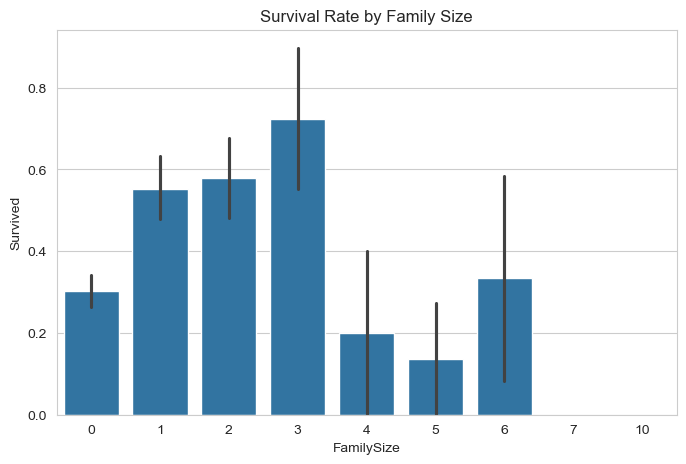

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="FamilySize",
    y="Survived",
    data=df
)

plt.title(
    "Survival Rate by Family Size"
)

plt.show()

### Insight

Passengers travelling with small families often had better survival rates.

# Required Visualization 1

## Age Distribution Histogram

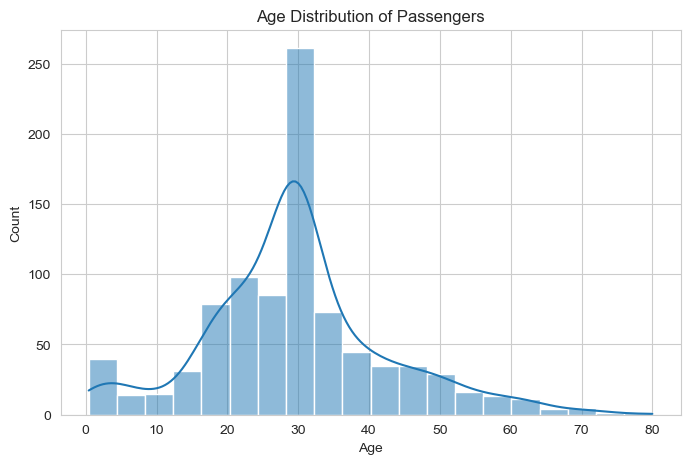

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)

plt.title(
    "Age Distribution of Passengers"
)

plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# Required Visualization 2

## Correlation Heatmap

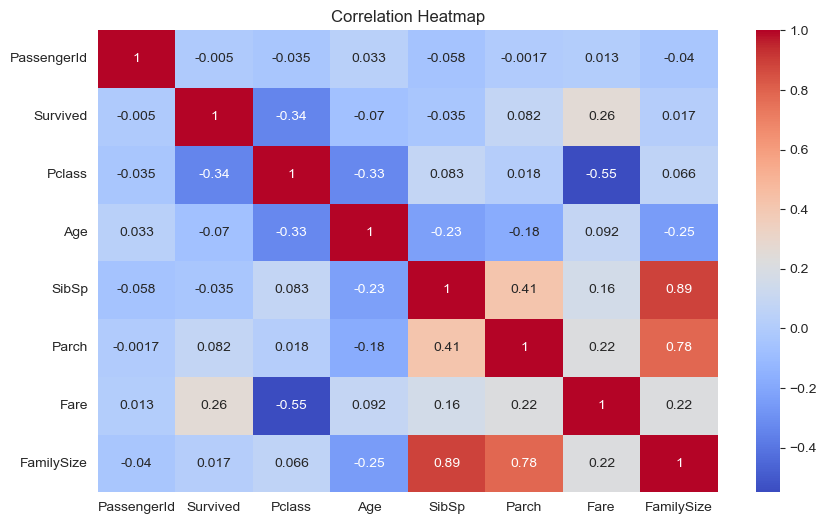

In [13]:
numeric_df = df.select_dtypes(
    include="number"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Insights

In [14]:
print("KEY INSIGHTS")

print(
    "\n1. Children had higher survival rates."
)

print(
    "\n2. Survival rates varied across embarkation ports."
)

print(
    "\n3. Family size influenced survival chances."
)

print(
    "\n4. Most passengers were young adults."
)

print(
    "\n5. Correlation analysis revealed relationships among passenger attributes."
)

KEY INSIGHTS

1. Children had higher survival rates.

2. Survival rates varied across embarkation ports.

3. Family size influenced survival chances.

4. Most passengers were young adults.

5. Correlation analysis revealed relationships among passenger attributes.


# Conclusion

The Titanic dataset was cleaned and analyzed using EDA techniques.

### Deliverables Covered

✅ Fill missing Age with mean

✅ Drop Cabin column

✅ Survival Rate by Age Group

✅ Survival Rate by Embarkation Port

✅ Survival Rate by Family Size

✅ Age Distribution Histogram

✅ Correlation Heatmap

✅ Survival by Family Size Bar Plot

✅ Multiple Insights

✅ Professional Visualizations